# CISC3024 Pattern Recognition - AI Assignment #2
## Variational Bayesian Last Layers (VBLL) for image classification with uncertainty estimation

**Algorithm:** Variational Bayesian Last Layers (VBLL) - Harrison, Willes & Snoek,
*ICLR 2024* (arXiv:2404.11599). A last-layer Bayesian treatment that keeps the
representational power of a deep feature extractor while making the probabilistic
part cheap: the variational posterior lives only on the final layer's weights.

**Task:** 10-class image classification plus predictive-uncertainty estimation.

**In-distribution (ID):** MNIST &nbsp;|&nbsp; **Out-of-distribution (OOD):** Fashion-MNIST

---

### The four arms compared

| # | Arm | Final layer | How probabilities are produced |
|---|-----|-------------|--------------------------------|
| a | `a_mlp_softmax` | `nn.Linear` + cross-entropy | softmax over raw logits |
| b | `b_vbll_disc` | `vbll.DiscClassification` | VBLL predictive (sampling-free) |
| c | `c_vbll_gen` | `vbll.GenClassification` | VBLL predictive (sampling-free) |
| d | `d_laplace_lla` | last-layer Laplace (`laplace-torch`) | GLM predictive + link approximation |

Arms (a)-(c) share an **identical** backbone, optimiser and data budget, so any
difference in the metrics is attributable to the final layer alone. Arm (d) is a
**post-hoc** method: it is wrapped around a network trained exactly like arm (a).

### What this notebook produces

* `outputs/results.csv`, `outputs/results.json` - Accuracy, NLL, ECE and OOD AUROC
  (two score families) for every arm
* `outputs/figures/sanity_data.png` - data sanity check
* `outputs/figures/reliability_diagram.png` - calibration of all four arms
* `outputs/figures/ood_histogram_native.png` - each arm's own OOD score
* `outputs/figures/ood_histogram_entropy.png` - the common, comparable entropy score
* `outputs/figures/risk_coverage.png` - selective prediction behaviour

> **Provenance.** Per the assignment rules, every line of code in this notebook was
> written by an AI assistant. The human operator supplied the specification, executed
> the notebook on Google Colab, and reported errors back to the assistant.

In [1]:
# =============================================================================
# Section 0 - dependency self-repair (hotfix for a recycled Colab session)
# =============================================================================
# Symptom this fixes
#     ModuleNotFoundError: No module named 'vbll'
#     raised by the "environment echo and fail-fast guards" cell further down.
#
# Cause
#     Colab discards every pip-installed package when a session is recycled or
#     the runtime disconnects. 00_colab_setup.ipynb did its job -- in a session
#     that no longer exists. The packages are gone, not broken.
#
# What this cell does
#     1. reports what is importable right now;
#     2. records Colab's OWN torch / torchvision versions into a constraints file;
#     3. installs vbll + laplace-torch (and the plain scientific stack) BEHIND
#        that constraint, so no transitive dependency can swap the CUDA build of
#        PyTorch for a CPU wheel and silently make cuda.is_available() False;
#     4. confirms torch.cuda.is_available() is still True afterwards.
#
# It is idempotent: run it as often as you like. If everything is already
# importable it only reports and exits without touching the environment, so it
# costs a couple of seconds on a healthy session.
# =============================================================================
import importlib
import pathlib
import platform
import subprocess
import sys
import warnings

# Importing laplace pulls in torch.jit users that emit deprecation warnings on
# modern torch. The notebook ignores warnings globally in its config cell; do the
# same here so this cell's output stays readable.
warnings.filterwarnings("ignore")

_NL = chr(10)


def _rule(title):
    print("=" * 68)
    print(title)
    print("=" * 68)


def _version(module_name):
    """Installed __version__ of a module, or None if it cannot be imported."""
    try:
        module = importlib.import_module(module_name)
    except Exception:
        return None
    return getattr(module, "__version__", "n/a")


def _base(version):
    """'2.6.0+cu124' -> '2.6.0'  (strip the local build tag)."""
    return str(version).split("+")[0]


# ---------------------------------------------------------------------------
# Step 0 - PyTorch must already exist. Colab always ships it; if it is missing
# the runtime is broken and no amount of pip will help.
# ---------------------------------------------------------------------------
try:
    import torch
    import torchvision
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "PyTorch itself is not importable ({}). The Colab runtime is broken, not "
        "merely missing packages. Use Runtime > Restart session, then run this "
        "cell again.".format(exc)
    ) from None

REQUIRED = ["torch", "torchvision", "numpy", "scipy", "pandas", "sklearn",
            "matplotlib", "seaborn", "tqdm", "vbll", "laplace"]

_rule("HOTFIX 1/4 - current state of the runtime")
print("  python       :", platform.python_version())
print("  torch        :", torch.__version__)
print("  torchvision  :", torchvision.__version__)
print("  CUDA runtime :", torch.version.cuda)
print("  GPU          :",
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE")
print()

_MISSING = [name for name in REQUIRED if _version(name) is None]
print("  missing      :", ", ".join(_MISSING) if _MISSING else "nothing")

# ---------------------------------------------------------------------------
# Step 1 - pin torch / torchvision to exactly what Colab already has
# ---------------------------------------------------------------------------
_rule("HOTFIX 2/4 - write the constraints file")
_CONSTRAINTS = pathlib.Path("colab-constraints.txt")
_CONSTRAINTS.write_text(_NL.join([
    "torch==" + _base(torch.__version__),
    "torchvision==" + _base(torchvision.__version__),
]) + _NL)

print("  wrote", _CONSTRAINTS.resolve())
print()
for _line in _CONSTRAINTS.read_text().rstrip().split(_NL):
    print("      " + _line)
print()
print("  ^ this is what stops pip replacing Colab's CUDA build of torch.")

# ---------------------------------------------------------------------------
# Step 2 - install everything else behind that constraint
# ---------------------------------------------------------------------------
_rule("HOTFIX 3/4 - install behind the constraint")

if not _MISSING:
    print("  nothing missing - skipping the install (this cell is idempotent).")
else:
    _PACKAGES = [
        "vbll==0.4.9",           # the algorithm under study (ICLR 2024)
        "laplace-torch==0.2.3",  # comparison baseline (last-layer Laplace)
        "numpy", "scipy", "pandas", "scikit-learn",
        "matplotlib", "seaborn", "tqdm",
    ]
    _cmd = [sys.executable, "-m", "pip", "install", "-q",
            "-c", str(_CONSTRAINTS), *_PACKAGES]
    print("  $ " + " ".join(_cmd))
    print()
    try:
        subprocess.run(_cmd, check=True)
    except subprocess.CalledProcessError as _exc:
        print()
        print("  INSTALL FAILED (exit code {}).".format(_exc.returncode))
        print("  Diagnose with these, pasted into a new cell:")
        print("      !{} -m pip check".format(sys.executable))
        print("      !{} -m pip install -c colab-constraints.txt "
              "vbll==0.4.9 laplace-torch==0.2.3 -v".format(sys.executable))
        raise

    # A running kernel caches the contents of site-packages, so a freshly
    # installed top-level package is not visible until those caches are dropped.
    importlib.invalidate_caches()
    sys.path_importer_cache.clear()
    for _name in [n for n in list(sys.modules)
                  if n.split(".")[0] in ("vbll", "laplace")]:
        del sys.modules[_name]
    print()
    print("  install finished; import caches dropped")

# ---------------------------------------------------------------------------
# Step 3 - verify: every import works AND torch was not disturbed
# ---------------------------------------------------------------------------
_rule("HOTFIX 4/4 - verify")
importlib.invalidate_caches()

print("  torch        :", torch.__version__, "   <- must be unchanged")
print("  CUDA runtime :", torch.version.cuda)
print()
print("  {:<12} {:<16} {}".format("module", "version", "status"))
print("  " + "-" * 42)

_still_missing = []
for _name in REQUIRED:
    _v = _version(_name)
    if _v is None:
        _still_missing.append(_name)
        print("  {:<12} {:<16} MISSING".format(_name, "-"))
    else:
        print("  {:<12} {:<16} OK".format(_name, _v))

print()
if _still_missing:
    print("  STILL MISSING:", ", ".join(_still_missing))
    print()
    print("  Python caches site-packages contents, so a package installed while")
    print("  the kernel is already running is sometimes not visible until the")
    print("  runtime restarts. Use Runtime > Restart session, then run this cell")
    print("  and Runtime > Run all.")
    raise RuntimeError("hotfix incomplete: {}".format(_still_missing))

if not torch.cuda.is_available():
    print("  !! torch.cuda.is_available() is False.")
    print("     The install did NOT break torch (the version above is unchanged),")
    print("     so the GPU was never attached. Fix it with:")
    print("       Runtime > Change runtime type > T4 GPU > Save")
    print("       Runtime > Restart session, then Runtime > Run all")
    print()
    print("  The environment is otherwise ready, so you can also continue on CPU")
    print("  by setting CFG['require_cuda'] = False in the config cell below.")
else:
    print("  GPU          :", torch.cuda.get_device_name(0))
    print()
    print("  HOTFIX OK - environment repaired, torch untouched, CUDA alive.")
    print("  Continue with the cells below (Runtime > Run all if you restarted).")

HOTFIX 1/4 - current state of the runtime
  python       : 3.13.15
  torch        : 2.11.0+cu130
  torchvision  : 0.26.0+cu130
  CUDA runtime : 13.0
  GPU          : Tesla T4

  missing      : vbll, laplace
HOTFIX 2/4 - write the constraints file
  wrote /content/colab-constraints.txt

      torch==2.11.0
      torchvision==0.26.0

  ^ this is what stops pip replacing Colab's CUDA build of torch.
HOTFIX 3/4 - install behind the constraint
  $ /usr/bin/python3 -m pip install -q -c colab-constraints.txt vbll==0.4.9 laplace-torch==0.2.3 numpy scipy pandas scikit-learn matplotlib seaborn tqdm


  install finished; import caches dropped
HOTFIX 4/4 - verify
  torch        : 2.11.0+cu130    <- must be unchanged
  CUDA runtime : 13.0

  module       version          status
  ------------------------------------------
  torch        2.11.0+cu130     OK
  torchvision  0.26.0+cu130     OK
  numpy        2.1.3            OK
  scipy        1.16.3           OK
  pandas       2.2.3            OK
  sk

In [2]:
# =============================================================================
# Section 0 - imports, global configuration, seeding
# =============================================================================
import os
import json
import time
import random
import warnings
import importlib.metadata as _md
from dataclasses import dataclass, field
from typing import Optional, Dict, Any, List, Tuple, Callable

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------------
# Device and global seed
# ----------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 0

# ----------------------------------------------------------------------------
# A single CFG mapping - every tunable lives here, so the report can quote it
# verbatim and an ablation is a one-line change.
# ----------------------------------------------------------------------------
CFG: Dict[str, Any] = {
    # reproducibility
    "seed": SEED,
    "seeds": [0, 1, 2],            # used by Section 6 only
    "require_cuda": True,          # fail fast if the Colab GPU is not enabled

    # data
    "data_dir": "./data",
    "val_frac": 0.10,
    "num_workers": 2,

    # shared model
    "in_dim": 28 * 28,
    "hidden": 256,
    "depth": 2,
    "num_classes": 10,

    # optimisation (identical for every arm)
    "epochs": 30,
    "batch_size": 512,
    "lr": 3e-3,
    "weight_decay": 0.0,           # must stay 0 for the VBLL head; see train_model
    "early_stop_patience": 8,

    # VBLL head
    "vbll_parameterization": "diagonal",   # {'diagonal', 'dense', 'lowrank'}
    "vbll_prior_scale": 1.0,
    "vbll_return_ood": True,               # the adapter REQUIRES this to be True

    # Laplace (arm d)
    "laplace_subset": "last_layer",
    "laplace_hessian": "kron",
    "laplace_pred_type": "glm",
    "laplace_link_approx": "sampled",      # 'sampled' -> 'mc' | 'deterministic' -> 'probit'
    "laplace_n_samples": 100,              # only used by link_approx='mc'
    "laplace_grid_size": 30,
    "laplace_log_prior_min": -4.0,
    "laplace_log_prior_max": 4.0,
    "laplace_batch_size": 512,             # batch the GLM predictive to avoid OOM
    "laplace_diagonal_output": False,

    # metrics
    "n_bins": 15,                          # equal-width ECE bins

    # outputs
    "out_dir": "outputs",
    "fig_dir": "outputs/figures",

    # Section 6 gate
    "run_robustness": False,
}

# The human-readable mode names mapped onto the values laplace-torch accepts.
# laplace-torch validates link_approx against {'mc', 'probit', 'bridge', 'bridge_norm'}.
LINK_APPROX_MAP = {"sampled": "mc", "deterministic": "probit"}

os.makedirs(CFG["out_dir"], exist_ok=True)
os.makedirs(CFG["fig_dir"], exist_ok=True)


def set_seed(seed: int) -> None:
    """Seed python, numpy and torch (CPU + CUDA) so a run is repeatable."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(CFG["seed"])

print("device      :", DEVICE)
print("torch       :", torch.__version__)
print("numpy       :", np.__version__)
print("output dir  :", os.path.abspath(CFG["out_dir"]))

device      : cuda
torch       : 2.11.0+cu130
numpy       : 2.1.3
output dir  : /content/outputs


In [3]:
# =============================================================================
# Section 0 - environment echo and fail-fast guards
# =============================================================================
def pkg_version(name: str) -> str:
    """Installed version of a distribution, or 'NOT-INSTALLED'."""
    try:
        return _md.version(name)
    except _md.PackageNotFoundError:
        return "NOT-INSTALLED"


# Import the two libraries the whole notebook depends on. If the setup notebook
# was not run, this fails here rather than fifteen cells later.
import vbll
from laplace import Laplace

ENV_INFO: Dict[str, Any] = {
    "device": str(DEVICE),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "numpy": np.__version__,
    "vbll": pkg_version("vbll"),
    "laplace-torch": pkg_version("laplace-torch"),
    "curvlinops-for-pytorch": pkg_version("curvlinops-for-pytorch"),
    "scikit-learn": pkg_version("scikit-learn"),
}

print("environment echo")
print("-" * 52)
for _k, _v in ENV_INFO.items():
    print("  {:<24} {}".format(_k, _v))

if CFG["require_cuda"] and not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. In Colab use Runtime > Change runtime type > "
        "T4 GPU and re-run. To deliberately run on CPU instead, set "
        "CFG['require_cuda'] = False."
    )

print()
print("guard passed: vbll and laplace-torch both import cleanly")

environment echo
----------------------------------------------------
  device                   cuda
  gpu_name                 Tesla T4
  torch                    2.11.0+cu130
  torchvision              0.26.0+cu130
  numpy                    2.1.3
  vbll                     0.4.9
  laplace-torch            0.2.3
  curvlinops-for-pytorch   3.0.1
  scikit-learn             1.6.1

guard passed: vbll and laplace-torch both import cleanly


### Reproducibility: what is fixed, and what is not

**Fixed**

* The global seed (`CFG['seed']`) is applied to `random`, `numpy` and `torch`.
* The train/validation split is carved **once**, from a `torch.Generator` seeded with
  `CFG['seed']`. Every arm and every seed run therefore sees exactly the same
  training data.
* The backbone, optimiser, learning rate, batch size and epoch budget are identical
  across arms (a)-(c). Arm (d) reuses the same recipe for its base network.
* Epochs are printed per arm and the best-validation-accuracy weights are restored
  before evaluation, so no arm is evaluated mid-training.

**Not fixed**

* **cuDNN is not put into deterministic mode.** Several cuDNN kernels are
  non-deterministic by default; forcing determinism costs throughput. For a
  coursework comparison of four heads this is an acceptable trade.
* **One seed per configuration** in the main run. Section 6 contains the multi-seed
  loop, but it is gated behind `CFG['run_robustness']` so the default run fits in a
  single Colab session.
* **The VBLL predictive averages a fixed number of internal Monte-Carlo samples**
  (20, hard-coded inside the library's `predictive()`), so the VBLL probabilities
  carry a small sampling noise of their own. This is a property of the library, not
  of this notebook. Rather than hide it, the notebook pins the RNG around every VBLL
  predictive call (`deterministic_mc`), which makes the reported numbers reproducible
  and gives the ID and OOD passes an identical noise pattern.

Consequence for the report: **differences smaller than the run-to-run noise should not
be interpreted as real**. Section 6 exists precisely to quantify that noise.

### Data: why MNIST in-distribution and Fashion-MNIST out-of-distribution

Both datasets are 28x28 greyscale images with **exactly 10 classes**. That is the
reason they are paired here:

* A **random** classifier scores ~0.10 accuracy on both, and any model that is
  calibrated will report ~0.10 confidence on average. So a large gap between
  accuracy and confidence is a genuine calibration failure, not an artefact of a
  label-space mismatch.
* Fashion-MNIST is *not* a perturbation of MNIST - it is a different image
  distribution (garments, not digits) drawn from the same sensor format. A model
  trained on MNIST has no reason to be confident on it, which is exactly what an OOD
  detector should notice.

**Normalisation.** We use the MNIST mean/std for *both* datasets. Applying
Fashion-MNIST's own statistics would mean the OOD set is pre-processed differently
from the ID set, and any resulting AUROC difference could be blamed on the
normalisation instead of on the model. Using one transform for both makes the OOD
test as clean as possible.

**The OOD test set is never used for any decision.** It is touched only inside
`evaluate_model`, after every model has been trained and every hyperparameter fixed.
The Laplace prior precision is tuned on the **validation** split of MNIST, never on
the test split and never on the OOD set.

In [4]:
# =============================================================================
# Section 1 - data
# =============================================================================
MEAN, STD = (0.1307,), (0.3081,)

train_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
eval_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

train_full = datasets.MNIST(CFG["data_dir"], train=True, download=True, transform=train_tf)
test_ds = datasets.MNIST(CFG["data_dir"], train=False, download=True, transform=eval_tf)
ood_ds = datasets.FashionMNIST(CFG["data_dir"], train=False, download=True, transform=eval_tf)

n_val = int(len(train_full) * CFG["val_frac"])
n_train = len(train_full) - n_val

# The split is carved ONCE, from a fixed-seed generator. Every arm and every seed
# run therefore trains and validates on exactly the same samples.
_split_gen = torch.Generator().manual_seed(CFG["seed"])
train_ds, val_ds = random_split(train_full, [n_train, n_val], generator=_split_gen)


def make_loader(ds, shuffle: bool, batch_size: Optional[int] = None) -> DataLoader:
    return DataLoader(
        ds,
        batch_size=batch_size if batch_size is not None else CFG["batch_size"],
        shuffle=shuffle,
        num_workers=CFG["num_workers"],
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )


train_loader = make_loader(train_ds, shuffle=True)
val_loader = make_loader(val_ds, shuffle=False)
test_loader = make_loader(test_ds, shuffle=False)
ood_loader = make_loader(ood_ds, shuffle=False)

print("train      {:>6d}".format(len(train_ds)))
print("val        {:>6d}".format(len(val_ds)))
print("test (ID)  {:>6d}".format(len(test_ds)))
print("OOD        {:>6d}".format(len(ood_ds)))

assert len(train_full) == 60000, "MNIST train split size changed"
assert len(train_ds) + len(val_ds) == len(train_full), "train/val split lost samples"
assert len(test_ds) == 10000, "MNIST test split size changed"
assert len(ood_ds) == 10000, "Fashion-MNIST test split size changed"
print("data guard: all four dataset sizes are as expected")

100%|██████████| 9.91M/9.91M [00:00<00:00, 61.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.72MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]
100%|██████████| 26.4M/26.4M [00:01<00:00, 17.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.8MB/s]

train       54000
val          6000
test (ID)   10000
OOD         10000
data guard: all four dataset sizes are as expected


saved outputs/figures/sanity_data.png
train class counts: [5274, 6089, 5387, 5538, 5249, 4860, 5305, 5646, 5292, 5360]
val   class counts: [649, 653, 571, 593, 593, 561, 613, 619, 559, 589]


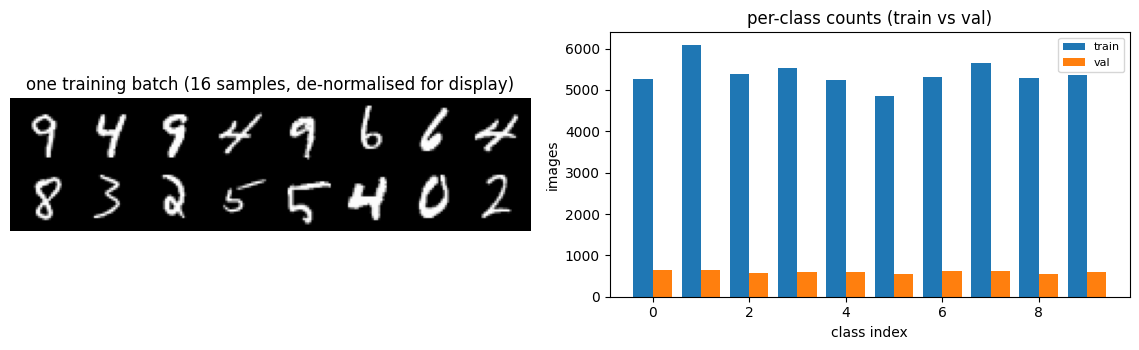

In [5]:
# =============================================================================
# Section 1 - data sanity check
# =============================================================================
# Catches a broken split, a broken transform or a mislabelled dataset before it
# costs an hour of GPU time.
_xb, _yb = next(iter(DataLoader(train_ds, batch_size=32, shuffle=True)))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))

grid = torchvision.utils.make_grid(_xb[:16], nrow=8, normalize=True)
axes[0].imshow(grid.permute(1, 2, 0).squeeze(-1).cpu().numpy(), cmap="gray")
axes[0].set_title("one training batch (16 samples, de-normalised for display)")
axes[0].axis("off")

_tr_counts = np.bincount(np.array([int(_y) for _, _y in train_ds]), minlength=10)
_va_counts = np.bincount(np.array([int(_y) for _, _y in val_ds]), minlength=10)
_w = 0.4
axes[1].bar(np.arange(10) - _w / 2, _tr_counts, width=_w, label="train")
axes[1].bar(np.arange(10) + _w / 2, _va_counts, width=_w, label="val")
axes[1].set_title("per-class counts (train vs val)")
axes[1].set_xlabel("class index")
axes[1].set_ylabel("images")
axes[1].legend(fontsize=8)

fig.tight_layout()
_sanity_path = os.path.join(CFG["fig_dir"], "sanity_data.png")
fig.savefig(_sanity_path, dpi=150)
print("saved", _sanity_path)
print("train class counts:", _tr_counts.tolist())
print("val   class counts:", _va_counts.tolist())

### The four arms, and what is held constant

All four arms are built on the **same backbone**: a 2-hidden-layer MLP with 256
units per layer and ReLU activations, consuming a flattened 784-dim image. The
backbone is identical in every arm, including arm (d)'s base network.

Held constant across arms:

| Factor | Value |
|---|---|
| Backbone | 2 x 256 ReLU MLP |
| Optimiser | AdamW |
| Learning rate | 3e-3 |
| Weight decay | 0 on the probabilistic head; `CFG['weight_decay']` on the trunk |
| Batch size | 512 |
| Epoch budget | 30, with early stopping on validation accuracy (patience 8) |
| Training data | the same fixed-seed 54,000/6,000 MNIST split |
| Selection | best validation accuracy, restored before evaluation |

Consequently, a difference in accuracy, NLL, ECE or AUROC between arms (a)-(c) is
attributable to **the final layer alone** - which is precisely the claim VBLL makes.
Arm (d) is deliberately *not* held to the same protocol, because last-layer Laplace is
a post-hoc procedure by construction: it starts from an already-trained network. That
asymmetry is a property of the method, and it is stated in the wrap-up.

In [6]:
# =============================================================================
# Section 2 - the shared backbone
# =============================================================================
class MLPBackbone(nn.Module):
    """Shared MLP trunk: `depth` hidden layers of `hidden` units with ReLU."""

    def __init__(self, in_dim: int = 784, hidden: int = 256, depth: int = 2):
        super().__init__()
        layers: List[nn.Module] = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.ReLU()]
            d = hidden
        self.features = nn.Sequential(*layers)
        self.out_dim = d

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        return self.features(x)


def build_backbone() -> MLPBackbone:
    return MLPBackbone(CFG["in_dim"], CFG["hidden"], CFG["depth"])


def count_params(model: nn.Module) -> int:
    """Trainable parameter count - a report artefact for the complexity comparison."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


_bb = build_backbone()
BACKBONE_PARAMS = count_params(_bb)
print("backbone output dim :", _bb.out_dim)
print("backbone params     :", BACKBONE_PARAMS)
del _bb

backbone output dim : 256
backbone params     : 266752


In [7]:
# =============================================================================
# Section 2 - arm (a): plain MLP + linear head
# =============================================================================
class PlainMLP(nn.Module):
    """Deterministic MLP with a linear classification head, trained with
    cross-entropy. This is the non-Bayesian control.

    forward() returns RAW LOGITS - softmax is applied by the adapter, once.
    """

    def __init__(self):
        super().__init__()
        self.backbone = build_backbone()
        self.head = nn.Linear(self.backbone.out_dim, CFG["num_classes"])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.backbone(x))


def build_plain_mlp() -> PlainMLP:
    return PlainMLP().to(DEVICE)


_m = build_plain_mlp()
print("arm (a) total params:", count_params(_m))
del _m

arm (a) total params: 269322


In [8]:
# =============================================================================
# Section 2 - arms (b) and (c): VBLL heads
# =============================================================================
# -----------------------------------------------------------------------------
# Device-safety shim for vbll 0.4.9 -- an upstream bug, not our code
# -----------------------------------------------------------------------------
# vbll allocates two helper identity matrices WITHOUT a `device=` argument, so they
# are created on the CPU while the model lives on the GPU:
#
#   vbll/utils/distributions.py:327
#       term2 = torch.linalg.det(arg1 + torch.eye(arg1.shape[-1])).log()
#       reached by LowRankNormal.logdet_covariance, i.e. parameterization='lowrank'
#   vbll/utils/distributions.py:27
#       torch.cholesky_solve(torch.eye(u.size(-1)).expand(u.size()), u, upper=upper)
#       reached by cholesky_inverse(), used by the precision parameterizations
#
# On a GPU run line 327 raises:
#   RuntimeError: Expected all tensors to be on the same device, but found at least
#   two devices, cuda:0 and cpu!
#
# The 'diagonal' parameterization never touches either line, which is why the main
# run (parameterization='diagonal') was unaffected and only the lowrank ablation arm
# failed. Editing site-packages is not an option: Colab discards it on every session
# recycle. Both functions are therefore replaced once, here, with equivalents that
# differ only in that the identity matrix inherits device and dtype from the tensor
# it is combined with. The math is otherwise identical to the library's.
import vbll.utils.distributions as _vbll_dist


def _lowrank_logdet_covariance(self):
    term1 = torch.log(self.cov_diag).sum(-1)
    arg1 = _vbll_dist.tp(self.cov_factor) @ (self.cov_factor / self.cov_diag.unsqueeze(-1))
    eye = torch.eye(arg1.shape[-1], device=arg1.device, dtype=arg1.dtype)
    return term1 + torch.linalg.det(arg1 + eye).log()


def _cholesky_inverse(u, upper=False):
    if u.dim() == 2 and not u.requires_grad:
        return torch.cholesky_inverse(u, upper=upper)
    eye = torch.eye(u.size(-1), device=u.device, dtype=u.dtype).expand(u.size())
    return torch.cholesky_solve(eye, u, upper=upper)


_vbll_dist.LowRankNormal.logdet_covariance = property(_lowrank_logdet_covariance)
_vbll_dist.cholesky_inverse = _cholesky_inverse

print("vbll device-safety shim installed (lowrank logdet + cholesky_inverse)")


class VBLLModel(nn.Module):
    """Backbone + VBLL head.

    forward() returns the library's VBLL output object, not a tensor. That object
    carries the predictive distribution, the training loss function, the validation
    loss function and (when return_ood=True) the OOD scores. The adapter is the only
    code that unpacks it.
    """

    def __init__(self, head: nn.Module):
        super().__init__()
        self.backbone = build_backbone()
        self.head = head

    def forward(self, x: torch.Tensor):
        return self.head(self.backbone(x))


def build_vbll_model(
    kind: str = "disc",
    reg_weight: Optional[float] = None,
    parameterization: Optional[str] = None,
    prior_scale: Optional[float] = None,
    return_ood: Optional[bool] = None,
) -> VBLLModel:
    """Factory for arms (b) and (c).

    kind='disc' -> vbll.DiscClassification  (discriminative, Jensen softmax bound)
    kind='gen'  -> vbll.GenClassification   (generative, class-conditional likelihood)

    Defaults come from CFG, and `return_ood` defaults to True because the adapter
    depends on `out.ood_scores` existing.
    """
    if parameterization is None:
        parameterization = CFG["vbll_parameterization"]
    if prior_scale is None:
        prior_scale = CFG["vbll_prior_scale"]
    if return_ood is None:
        return_ood = CFG["vbll_return_ood"]
    if reg_weight is None:
        # The ELBO regularisation term is scaled by 1/N so that it stays
        # comparable with the data term as the dataset grows.
        reg_weight = 1.0 / len(train_ds)

    in_features = CFG["hidden"]

    if kind == "disc":
        head = vbll.DiscClassification(
            in_features=in_features,
            out_features=CFG["num_classes"],
            regularization_weight=reg_weight,
            parameterization=parameterization,
            return_ood=return_ood,
            prior_scale=prior_scale,
        )
    elif kind == "gen":
        head = vbll.GenClassification(
            in_features=in_features,
            out_features=CFG["num_classes"],
            regularization_weight=reg_weight,
            parameterization=parameterization,
            return_ood=return_ood,
            prior_scale=prior_scale,
        )
    else:
        raise ValueError("kind must be 'disc' or 'gen', got {!r}".format(kind))

    return VBLLModel(head).to(DEVICE)


print("arm (b) total params:", count_params(build_vbll_model("disc")))
print("arm (c) total params:", count_params(build_vbll_model("gen")))
print("VBLL regularisation weight (1/N_train):", 1.0 / len(train_ds))

arm (b) total params: 271882
arm (c) total params: 272128
VBLL regularisation weight (1/N_train): 1.8518518518518518e-05


In [9]:
# =============================================================================
# Section 2 - arm (d): the base network for last-layer Laplace
# =============================================================================
# Last-layer Laplace is a POST-HOC method: it does not change how the network is
# trained. Arm (d) therefore starts from an ordinary PlainMLP trained with exactly
# the same recipe as arm (a). The Laplace posterior over the last layer's weights is
# fitted afterwards, in the training cell.
def build_laplace_base() -> PlainMLP:
    return PlainMLP().to(DEVICE)


print("arm (d) base network params:", count_params(build_laplace_base()))
print("the Laplace posterior is fitted later, once this network is trained")

arm (d) base network params: 269322
the Laplace posterior is fitted later, once this network is trained


## The evaluation contract - the core of this notebook

### The problem

The four arms return four different things:

| Arm | What a forward pass returns | How probabilities are obtained | How an OOD score is obtained |
|---|---|---|---|
| (a) MLP + softmax | raw logits `(N, C)` | apply softmax | `1 - max p` |
| (b) VBLL Disc | a VBLL output object | read `out.predictive.probs` | read `out.ood_scores` |
| (c) VBLL Gen | a VBLL output object | read `out.predictive.probs` | read `out.ood_scores` |
| (d) Laplace LLA | probabilities (GLM predictive) | already normalised | **nothing native** - must be derived |

Three of the four need different post-processing, and arm (d) has no OOD score at all.
If the evaluation code handled these cases itself it would need an
`if arm == ...` ladder, which breaks the moment an arm is added or changed.

### The decision: an adapter (port) layer

Each arm is wrapped in a thin adapter exposing **one** method:

```
predict(loader) -> Prediction
```

`evaluate_model` only ever sees a `Prediction`. It never sees a model, a logit tensor
or a VBLL output object. Adding a fifth arm later means writing one adapter - no change
to the metrics or the plotting code.

### The `Prediction` contract

| Field | Shape | Meaning |
|---|---|---|
| `probs` | `(N, C)` | predictive class probabilities, rows sum to 1 |
| `logits` | `(N, C)` | raw scores, kept for provenance |
| `ood_score` | `(N,)` | **higher = more out-of-distribution** |
| `n` | scalar | sample count |
| `uncertainty_aleatoric` | `(N,)` or `None` | VBLL arms only |
| `uncertainty_epistemic` | `(N,)` or `None` | VBLL arms only |
| `extra` | dict | provenance: link approximation, sample counts, score definitions |

### Invariants - asserted inside the adapter, never inside `evaluate_model`

* `probs.shape == (n, C)` and `ood_score.shape == (n,)`
* `probs` rows sum to 1 within `1e-4`
* all values in `[0, 1]`, no `NaN`, no `inf`
* `n` equals the length of the dataset behind the loader

Putting validation in the adapter means a malformed prediction is caught by the arm
that produced it, with that arm's name in the message.

### The two rules that protect the result

1. **No second softmax.** The VBLL heads and the Laplace GLM predictive already return
   normalised probabilities. Applying softmax again would silently destroy the very
   calibration this notebook is measuring, and nothing downstream would look wrong.
   The adapters are the only place probabilities are produced, and neither applies
   softmax to a VBLL or Laplace output.
2. **No Monte-Carlo loop around VBLL.** VBLL's predictive is sampling-free by design;
   one forward pass is enough. Wrapping it in an MC loop would misrepresent the
   method's main selling point.

### Fairness: making the four OOD scores comparable

The four arms score OOD-ness with three different definitions, and one of them
(`out.ood_scores`) is a likelihood-based quantity that the others simply do not have.
Reporting a single AUROC column would compare four different things.

**The notebook therefore reports two score families:**

* `auroc_native` - each arm's own score. This is what the method *claims*, and it is
  the headline number for VBLL.
* `auroc_entropy` - the predictive entropy `H[p]`, computable from `probs` for **all
  four** arms. This is the apples-to-apples comparison.

Note on sign conventions: the VBLL library defines `ood_scores` as the **maximum
predictive probability**, where a *large* value means *more* in-distribution. The
adapter flips it (`1 - max p`) so that the `Prediction` contract - higher means more
OOD - holds for every arm. AUROC is then computed with the OOD samples as the positive
class, so a healthy detector scores above 0.5.

In [10]:
# =============================================================================
# Section 3 - the Prediction container and its validator
# =============================================================================
from contextlib import contextmanager, nullcontext


@contextmanager
def deterministic_mc(seed: int):
    """Pin the RNG for the duration of a VBLL predictive call.

    VBLL's `predictive()` averages a FIXED number of internal Monte-Carlo samples
    (20, hard-coded in the library), so its output is stochastic even though the
    method itself is sampling-free. Pinning the RNG here
      * makes the reported numbers reproducible run to run, and
      * gives the ID pass and the OOD pass the same noise pattern.
    The caller's RNG state is restored afterwards, so training is unaffected.
    """
    state = torch.get_rng_state()
    cuda_state = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    torch.manual_seed(seed)
    try:
        yield
    finally:
        torch.set_rng_state(state)
        if cuda_state is not None:
            torch.cuda.set_rng_state_all(cuda_state)


@dataclass
class Prediction:
    """The only thing evaluate_model ever consumes."""

    probs: np.ndarray
    logits: Optional[np.ndarray] = None
    ood_score: Optional[np.ndarray] = None          # higher == more OOD
    uncertainty_aleatoric: Optional[np.ndarray] = None
    uncertainty_epistemic: Optional[np.ndarray] = None
    extra: Dict[str, Any] = field(default_factory=dict)

    @property
    def n(self) -> int:
        return int(self.probs.shape[0])


def check_contract(pred: Prediction, arm_name: str, expected_n: Optional[int] = None,
                   tol: float = 1e-4) -> bool:
    """Assert every invariant of the Prediction contract.

    Called by each adapter on its OWN output, so a violation names the arm that
    caused it instead of surfacing later inside the metrics.
    """
    if not isinstance(pred, Prediction):
        raise TypeError("[{}] predict() must return a Prediction, got {}".format(
            arm_name, type(pred).__name__))

    p = np.asarray(pred.probs, dtype=np.float64)
    if p.ndim != 2:
        raise ValueError("[{}] probs must be 2-D (N, C); got shape {}".format(arm_name, p.shape))
    n, c = p.shape

    if expected_n is not None and n != expected_n:
        raise ValueError("[{}] probs has N={}, but the dataset has {}".format(
            arm_name, n, expected_n))
    if c != CFG["num_classes"]:
        raise ValueError("[{}] probs has C={}, expected {}".format(
            arm_name, c, CFG["num_classes"]))
    if not np.isfinite(p).all():
        raise ValueError("[{}] probs contains NaN or inf".format(arm_name))
    if p.min() < -1e-6 or p.max() > 1.0 + 1e-6:
        raise ValueError("[{}] probs outside [0, 1] (min={:.6g}, max={:.6g})".format(
            arm_name, p.min(), p.max()))

    row_sum = p.sum(axis=1)
    if not np.allclose(row_sum, 1.0, atol=tol):
        raise ValueError("[{}] probs rows do not sum to 1 "
                         "(min={:.8f}, max={:.8f})".format(arm_name, row_sum.min(), row_sum.max()))

    if pred.ood_score is not None:
        s = np.asarray(pred.ood_score, dtype=np.float64)
        if s.shape != (n,):
            raise ValueError("[{}] ood_score must have shape ({},); got {}".format(
                arm_name, n, s.shape))
        if not np.isfinite(s).all():
            raise ValueError("[{}] ood_score contains NaN or inf".format(arm_name))

    for _fld in ("uncertainty_aleatoric", "uncertainty_epistemic"):
        _v = getattr(pred, _fld)
        if _v is not None and np.asarray(_v).shape != (n,):
            raise ValueError("[{}] {} must have shape ({},); got {}".format(
                arm_name, _fld, n, np.asarray(_v).shape))

    return True


def collect_targets(loader: DataLoader) -> np.ndarray:
    """Labels of a loader, in the same order the adapter concatenated its batches.

    The loaders yield CPU tensors, so this is already device-safe; the `.cpu()` is
    defensive so the helper stays correct if a loader is ever changed to yield
    device tensors.
    """
    ys = []
    for _, y in loader:
        if isinstance(y, torch.Tensor):
            y = y.detach().cpu()
        ys.append(np.asarray(y))
    return np.concatenate(ys, axis=0)


def predictive_entropy(probs: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """H[p] in nats. Defined for every arm, which is what makes it the fair score."""
    p = np.clip(np.asarray(probs, dtype=np.float64), eps, 1.0)
    return -(p * np.log(p)).sum(axis=1)

In [11]:
# =============================================================================
# Section 3 - the three adapters
# =============================================================================
class BaselineAdapter:
    """Arm (a). Raw logits -> softmax, once. ood_score = 1 - max p."""

    def __init__(self, model: nn.Module, name: str = "a_mlp_softmax"):
        self.model = model
        self.name = name

    @torch.no_grad()
    def predict(self, loader: DataLoader) -> Prediction:
        self.model.eval()
        logits_chunks, prob_chunks = [], []
        for x, _ in loader:
            z = self.model(x.to(DEVICE))
            logits_chunks.append(z.detach().cpu().numpy())
            prob_chunks.append(F.softmax(z, dim=-1).detach().cpu().numpy())

        logits = np.concatenate(logits_chunks, axis=0).astype(np.float64)
        probs = np.concatenate(prob_chunks, axis=0).astype(np.float64)

        pred = Prediction(
            probs=probs,
            logits=logits,
            ood_score=(1.0 - probs.max(axis=1)).astype(np.float64),
            extra={"source": "softmax", "ood_score_definition": "1 - max p"},
        )
        check_contract(pred, self.name, expected_n=len(loader.dataset))
        return pred


class VBLLAdapter:
    """Arms (b) and (c). Reads the VBLL output object directly.

    Two things deliberately do NOT happen here:
      * no softmax - the VBLL head already returns normalised probabilities;
      * no Monte-Carlo loop - VBLL's predictive is sampling-free by design.
    """

    def __init__(self, model: nn.Module, name: str):
        self.model = model
        self.name = name

    @torch.no_grad()
    def predict(self, loader: DataLoader) -> Prediction:
        self.model.eval()
        prob_chunks, ood_chunks = [], []

        # vbll's predictive() is stochastic (it averages 20 internal MC samples),
        # so pin the RNG to make the reported numbers reproducible.
        with deterministic_mc(CFG["seed"]):
            for x, _ in loader:
                x = x.to(DEVICE)
                out = self.model(x)

                # Fail loudly and by name if the head was built without return_ood.
                raw_ood = getattr(out, "ood_scores", None)
                if raw_ood is None:
                    raise RuntimeError(
                        "[{}] the VBLL head was built with return_ood=False, so "
                        "out.ood_scores does not exist. Rebuild it with "
                        "CFG['vbll_return_ood'] = True.".format(self.name))
                if callable(raw_ood):
                    raw_ood = raw_ood(x)

                # out.predictive is already a normalised Categorical -> read .probs.
                prob_chunks.append(out.predictive.probs.detach().cpu().numpy())
                ood_chunks.append(raw_ood.detach().cpu().numpy().reshape(-1))

        probs = np.concatenate(prob_chunks, axis=0).astype(np.float64)
        ood_raw = np.concatenate(ood_chunks, axis=0).astype(np.float64)

        # vbll defines ood_scores as the MAX PREDICTIVE PROBABILITY:
        # a large value means "confident", i.e. in-distribution. Flip it so that
        # the Prediction contract (higher == more OOD) holds for every arm.
        ood_score = (1.0 - ood_raw).astype(np.float64)

        pred = Prediction(
            probs=probs,
            logits=np.log(np.clip(probs, 1e-12, 1.0)),
            ood_score=ood_score,
            extra={
                "source": "vbll",
                "vbll_ood_raw_definition": "max predictive probability",
                "ood_score_transform": "1 - max_predictive",
                "mc_samples_inside_head": 20,
            },
        )
        check_contract(pred, self.name, expected_n=len(loader.dataset))
        return pred


class LaplaceAdapter:
    """Arm (d). laplace-torch returns normalised probabilities from its GLM
    predictive, so again no softmax is applied here.

    laplace-torch has NO native OOD score. It is therefore DERIVED from the
    predictive distribution. That is a genuine methodological asymmetry with the
    VBLL arms, which is exactly why the notebook also reports the common entropy
    score family.
    """

    def __init__(self, la, name: str = "d_laplace_lla", link_approx: str = "probit",
                 n_samples: int = 100, batch_size: int = 512,
                 diagonal_output: bool = False):
        self.la = la
        self.name = name
        self.link_approx = link_approx
        self.n_samples = n_samples
        self.batch_size = batch_size
        self.diagonal_output = diagonal_output

    @torch.no_grad()
    def predict(self, loader: DataLoader) -> Prediction:
        self.la.model.eval()
        outer = []

        for x, _ in loader:
            x = x.to(DEVICE)
            # The GLM predictive is the heaviest step in the notebook: batch it so
            # a large test set cannot exhaust memory.
            inner = []
            for i in range(0, x.shape[0], self.batch_size):
                xb = x[i:i + self.batch_size]
                p = self.la(
                    xb,
                    pred_type=CFG["laplace_pred_type"],
                    link_approx=self.link_approx,
                    n_samples=self.n_samples,
                    diagonal_output=self.diagonal_output,
                )
                inner.append(p.detach().cpu().numpy())
            outer.append(np.concatenate(inner, axis=0))

        probs = np.concatenate(outer, axis=0).astype(np.float64)
        # Numerical guard only - the link approximations are already normalised.
        probs = probs / probs.sum(axis=1, keepdims=True)

        pred = Prediction(
            probs=probs,
            logits=np.log(np.clip(probs, 1e-12, 1.0)),
            ood_score=(1.0 - probs.max(axis=1)).astype(np.float64),
            extra={
                "source": "laplace_glm",
                "link_approx": self.link_approx,
                "n_samples": self.n_samples,
                "hessian_structure": CFG["laplace_hessian"],
                "ood_score_definition": "derived: 1 - max p",
            },
        )
        check_contract(pred, self.name, expected_n=len(loader.dataset))
        return pred

In [12]:
# =============================================================================
# Section 3 - metrics: pure functions of arrays
# =============================================================================
# No model, no loader, no device. That makes each one independently checkable,
# which matters because a wrong ECE silently invalidates a headline claim.
def accuracy(probs: np.ndarray, y: np.ndarray) -> float:
    probs = np.asarray(probs)
    y = np.asarray(y)
    return float((probs.argmax(axis=1) == y).mean())


def nll(probs: np.ndarray, y: np.ndarray, eps: float = 1e-12) -> float:
    probs = np.asarray(probs, dtype=np.float64)
    y = np.asarray(y)
    p_true = np.clip(probs[np.arange(len(y)), y], eps, 1.0)
    return float(-np.log(p_true).mean())


def ece(probs: np.ndarray, y: np.ndarray, n_bins: int = 15):
    """Expected Calibration Error with EQUAL-WIDTH bins.

    Returns the scalar ECE *plus* the bin arrays, so the reliability diagram is a
    by-product of the metric and can never drift out of sync with the number
    printed in the results table.

    Returns
    -------
    (ece_value, bin_conf, bin_acc, bin_count, bin_edges)
    """
    probs = np.asarray(probs, dtype=np.float64)
    y = np.asarray(y)

    conf = probs.max(axis=1)
    correct = (probs.argmax(axis=1) == y).astype(np.float64)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    # Interior edges only; np.digitize then yields 0..n_bins, clipped to n_bins-1
    # so that confidence == 1.0 lands in the last bin rather than falling off.
    bin_ids = np.clip(np.digitize(conf, edges[1:-1], right=False), 0, n_bins - 1)

    bin_count = np.zeros(n_bins, dtype=np.float64)
    bin_conf = np.zeros(n_bins, dtype=np.float64)
    bin_acc = np.zeros(n_bins, dtype=np.float64)

    for b in range(n_bins):
        m = bin_ids == b
        cnt = int(m.sum())
        bin_count[b] = cnt
        if cnt > 0:
            bin_conf[b] = conf[m].mean()
            bin_acc[b] = correct[m].mean()

    total = float(len(conf))
    ece_value = float(np.sum(bin_count / total * np.abs(bin_acc - bin_conf)))
    return ece_value, bin_conf, bin_acc, bin_count, edges


def ece_equal_mass(probs: np.ndarray, y: np.ndarray, n_bins: int = 15) -> float:
    """Expected Calibration Error with EQUAL-MASS (adaptive) bins.

    The standard alternative to the equal-width default, and the reason it matters:
    on a saturated benchmark such as MNIST almost every test sample lands in the
    top equal-width bin, so the equal-width estimator is effectively dominated by
    that one bin. Equal-mass binning splits the samples into `n_bins` groups of
    roughly equal size, which weights the low-confidence region far more heavily.

    Reporting both makes the sensitivity of the headline ECE to the binning choice
    explicit instead of leaving it hidden. Equal-width remains the default because
    it is the more common convention.

    Caveat: equal-mass binning needs n_bins << N. If n_bins approaches N every bin
    holds a single sample, whose "empirical accuracy" is 0 or 1, and the estimator
    degenerates. With N = 10000 and n_bins = 15 that is far from a concern.
    """
    probs = np.asarray(probs, dtype=np.float64)
    y = np.asarray(y)

    conf = probs.max(axis=1)
    correct = (probs.argmax(axis=1) == y).astype(np.float64)

    order = np.argsort(conf)
    conf_sorted = conf[order]
    correct_sorted = correct[order]

    groups = np.array_split(np.arange(len(conf_sorted)), n_bins)
    total = float(len(conf_sorted))

    ece_value = 0.0
    for g in groups:
        if len(g) == 0:
            continue
        ece_value += (len(g) / total) * abs(correct_sorted[g].mean() - conf_sorted[g].mean())
    return float(ece_value)


def auroc(scores_id: np.ndarray, scores_ood: np.ndarray) -> float:
    """AUROC with the OOD samples as the positive class.

    Inputs follow the Prediction convention: higher score == more OOD, so a healthy
    detector scores above 0.5. An arm that returns a consistently inverted score
    yields AUROC < 0.5 - that is a signal, and it is deliberately kept visible
    instead of being auto-flipped.
    """
    s_id = np.asarray(scores_id, dtype=np.float64)
    s_ood = np.asarray(scores_ood, dtype=np.float64)
    y = np.concatenate([np.zeros(len(s_id)), np.ones(len(s_ood))])
    s = np.concatenate([s_id, s_ood])
    return float(roc_auc_score(y, s))

In [13]:
# =============================================================================
# Section 3 - evaluate_model: the single entry point
# =============================================================================
def evaluate_model(adapter, id_loader: DataLoader, ood_loader: DataLoader,
                   n_bins: Optional[int] = None) -> Dict[str, Any]:
    """Run one adapter over the ID and OOD loaders and return every number and
    every array the report needs.

    This function never inspects a model type. It only ever touches Predictions.
    """
    n_bins = CFG["n_bins"] if n_bins is None else n_bins

    pred_id = adapter.predict(id_loader)
    pred_ood = adapter.predict(ood_loader)

    # Re-validate at the boundary too: cheap, and it means a contract violation can
    # never leak into the metrics.
    check_contract(pred_id, adapter.name, expected_n=len(id_loader.dataset))
    check_contract(pred_ood, adapter.name, expected_n=len(ood_loader.dataset))

    y_id = collect_targets(id_loader)

    ece_value, bin_conf, bin_acc, bin_count, bin_edges = ece(pred_id.probs, y_id, n_bins=n_bins)

    # The same metric under the other binning convention. On a saturated benchmark
    # the two can differ by a lot, so both are reported rather than one being
    # chosen silently.
    ece_em = ece_equal_mass(pred_id.probs, y_id, n_bins=n_bins)

    # family 1 - each arm's own score (this is what the method claims)
    auroc_native = auroc(pred_id.ood_score, pred_ood.ood_score)

    # family 2 - predictive entropy, computable for ALL four arms (fair comparison)
    ent_id = predictive_entropy(pred_id.probs)
    ent_ood = predictive_entropy(pred_ood.probs)
    auroc_entropy = auroc(ent_id, ent_ood)

    return {
        "arm": adapter.name,
        "n_id": int(pred_id.n),
        "n_ood": int(pred_ood.n),

        "accuracy": accuracy(pred_id.probs, y_id),
        "nll": nll(pred_id.probs, y_id),
        "ece": ece_value,
        "ece_equal_mass": ece_em,
        "auroc_native": auroc_native,
        "auroc_entropy": auroc_entropy,
        "n_bins": n_bins,

        # per-sample arrays consumed by the plots
        "y_id": y_id,
        "probs_id": pred_id.probs,
        "probs_ood": pred_ood.probs,
        "ood_score_id": pred_id.ood_score,
        "ood_score_ood": pred_ood.ood_score,
        "entropy_id": ent_id,
        "entropy_ood": ent_ood,
        "bin_conf": bin_conf,
        "bin_acc": bin_acc,
        "bin_count": bin_count,
        "bin_edges": bin_edges,

        # provenance, so the report can state exactly what produced the numbers
        "extra": dict(pred_id.extra),
    }

In [14]:
# =============================================================================
# Section 4 - one training loop for both objectives
# =============================================================================
def _is_vbll_model(model: nn.Module) -> bool:
    return isinstance(model, VBLLModel)


def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
                cfg: Optional[Dict[str, Any]] = None, tag: str = ""):
    """Unified training loop.

    * arm (a) and arm (d)'s base network -> nn.CrossEntropyLoss on raw logits
    * arms (b) and (c) -> the VBLL ELBO, differentiated through
      out.train_loss_fn(y), with out.val_loss_fn(y) for validation

    The VBLL head is excluded from weight decay. Its prior term already regularises
    it (and the ELBO is scaled by reg_weight = 1/N), so adding weight decay would
    double-count the prior.

    Early stopping is on validation accuracy; the best weights are restored before
    returning, so no arm is ever evaluated mid-training.
    """
    cfg = CFG if cfg is None else cfg
    is_vbll = _is_vbll_model(model)

    head_params = list(model.head.parameters()) if is_vbll else []
    head_ids = {id(p) for p in head_params}
    trunk_params = [p for p in model.parameters() if id(p) not in head_ids]

    groups = [{"params": trunk_params, "weight_decay": cfg["weight_decay"]}]
    if head_params:
        groups.append({"params": head_params, "weight_decay": 0.0})
    opt = torch.optim.AdamW(groups, lr=cfg["lr"])

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best = {"val_acc": -1.0, "epoch": -1, "state": None}
    patience_left = cfg["early_stop_patience"]

    for epoch in range(1, cfg["epochs"] + 1):
        t0 = time.time()

        # ---------------- train ----------------
        model.train()
        run_loss, n_seen = 0.0, 0
        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)

            if is_vbll:
                out = model(x)
                loss = out.train_loss_fn(y)          # the negative ELBO
            else:
                loss = F.cross_entropy(model(x), y)

            loss.backward()
            opt.step()

            run_loss += float(loss.detach()) * x.size(0)
            n_seen += x.size(0)
        train_loss = run_loss / max(n_seen, 1)

        # ---------------- validate ----------------
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        # For VBLL the predictive is stochastic, so validation accuracy would wobble
        # between epochs and early stopping would fire on MC noise rather than on a
        # real change. Pinning the RNG for the validation pass only makes the
        # epoch-to-epoch comparison meaningful without perturbing training.
        _mc_ctx = deterministic_mc(cfg["seed"]) if is_vbll else nullcontext()
        with _mc_ctx:
            with torch.no_grad():
                for x, y in val_loader:
                    x = x.to(DEVICE, non_blocking=True)
                    y = y.to(DEVICE, non_blocking=True)
                    if is_vbll:
                        out = model(x)
                        val_loss += float(out.val_loss_fn(y).detach()) * x.size(0)
                        pred = out.predictive.probs.argmax(dim=-1)
                    else:
                        z = model(x)
                        val_loss += float(F.cross_entropy(z, y).detach()) * x.size(0)
                        pred = z.argmax(dim=-1)
                    correct += int((pred == y).sum())
                    total += x.size(0)
        val_loss /= max(total, 1)
        val_acc = correct / max(total, 1)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        improved = val_acc > best["val_acc"]
        if improved:
            best = {
                "val_acc": val_acc,
                "epoch": epoch,
                "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            }
            patience_left = cfg["early_stop_patience"]
        else:
            patience_left -= 1

        print("  [{:<15}] epoch {:>3d}/{}  train_loss={:9.4f}  val_loss={:9.4f}  "
              "val_acc={:.4f}  ({:.1f}s){}".format(
                  tag, epoch, cfg["epochs"], train_loss, val_loss, val_acc,
                  time.time() - t0, "  *" if improved else ""))

        if patience_left <= 0:
            print("  [{:<15}] early stop at epoch {} (best epoch {})".format(
                tag, epoch, best["epoch"]))
            break

    if best["state"] is not None:
        model.load_state_dict(best["state"])
    return history, best

In [15]:
# =============================================================================
# Section 4 - run the arms, then fit the Laplace posterior
# =============================================================================
ARM_SPECS = [
    ("a_mlp_softmax", lambda: build_plain_mlp(), "plain MLP + softmax"),
    ("b_vbll_disc", lambda: build_vbll_model("disc"), "VBLL DiscClassification"),
    ("c_vbll_gen", lambda: build_vbll_model("gen"), "VBLL GenClassification"),
]


def fit_laplace(base_model: nn.Module, train_loader: DataLoader,
                val_loader: DataLoader, cfg: Dict[str, Any]):
    """Post-hoc last-layer Laplace around an already-trained network.

    Hyperparameters (the prior precision) are optimised against the VALIDATION
    split - never the test split, never the OOD set.
    """
    link_approx = LINK_APPROX_MAP[cfg["laplace_link_approx"]]

    la = Laplace(
        base_model,
        likelihood="classification",
        subset_of_weights=cfg["laplace_subset"],
        hessian_structure=cfg["laplace_hessian"],
    )
    print("  fitting the last-layer Laplace posterior on the TRAIN split ...")
    la.fit(train_loader)

    print("  optimising the prior precision on the VALIDATION split "
          "(link_approx='{}') ...".format(link_approx))
    la.optimize_prior_precision(
        pred_type=cfg["laplace_pred_type"],
        method="gridsearch",
        prior_structure="scalar",
        val_loader=val_loader,
        link_approx=link_approx,
        n_samples=cfg["laplace_n_samples"],
        grid_size=cfg["laplace_grid_size"],
        log_prior_prec_min=cfg["laplace_log_prior_min"],
        log_prior_prec_max=cfg["laplace_log_prior_max"],
        progress_bar=False,
    )
    # laplace-torch's prior_precision SETTER moves the tensor onto the model's own
    # device (baselaplace.py: `prior_precision.to(device=self._device)`), so on a GPU
    # this is a cuda:0 tensor and np.asarray on it raises
    #   TypeError: can't convert cuda:0 device type tensor to numpy.
    # That failure is invisible on CPU, which is why the CPU-only verification missed
    # it. Always go through .cpu() before handing a library tensor to numpy.
    _pp = la.prior_precision
    if isinstance(_pp, torch.Tensor):
        _pp = _pp.detach().cpu()
    pp = float(np.asarray(_pp).reshape(-1)[0])
    print("  selected prior precision: {:.6g}".format(pp))
    return la, pp


def run_pipeline(seed: int, cfg: Optional[Dict[str, Any]] = None,
                 verbose: bool = True) -> Dict[str, Any]:
    """Train all four arms from scratch under one seed and return them.

    Defined as a function so Section 6 can reuse it for the multi-seed loop
    without duplicating a single line.
    """
    cfg = CFG if cfg is None else cfg
    set_seed(seed)

    models: Dict[str, nn.Module] = {}
    histories: Dict[str, Dict[str, list]] = {}
    bests: Dict[str, Dict[str, Any]] = {}

    for name, factory, label in ARM_SPECS:
        if verbose:
            print("=" * 74)
            print("training {}  ({})".format(name, label))
            print("=" * 74)
        model = factory()
        hist, best = train_model(model, train_loader, val_loader, cfg, tag=name)
        models[name] = model
        histories[name] = hist
        bests[name] = best
        torch.save(best["state"], os.path.join(cfg["out_dir"], "{}_best.pt".format(name)))
        if verbose:
            print("  best val_acc = {:.4f} (epoch {}) | params = {}".format(
                best["val_acc"], best["epoch"], count_params(model)))
            print()

    # ---- arm (d): post-hoc Laplace around a network trained like arm (a) ----
    if verbose:
        print("=" * 74)
        print("training d_laplace_lla  (plain MLP; the Laplace part is post-hoc)")
        print("=" * 74)
    base = build_laplace_base()
    hist_d, best_d = train_model(base, train_loader, val_loader, cfg, tag="d_laplace_base")
    histories["d_laplace_lla"] = hist_d
    bests["d_laplace_lla"] = best_d
    torch.save(best_d["state"], os.path.join(cfg["out_dir"], "d_laplace_lla_best.pt"))
    if verbose:
        print("  base MLP best val_acc = {:.4f}".format(best_d["val_acc"]))

    la, prior_prec = fit_laplace(base, train_loader, val_loader, cfg)
    models["d_laplace_lla"] = base

    return {
        "seed": seed,
        "models": models,
        "laplace": la,
        "prior_precision": prior_prec,
        "histories": histories,
        "bests": bests,
    }


# ---------------------------------------------------------------------------
# The single-seed main run
# ---------------------------------------------------------------------------
RUN = run_pipeline(CFG["seed"], CFG, verbose=True)

trained_models = RUN["models"]
la = RUN["laplace"]
HISTORIES = RUN["histories"]
print()
print("all four arms trained. Laplace prior precision = {:.6g}".format(RUN["prior_precision"]))

training a_mlp_softmax  (plain MLP + softmax)
  [a_mlp_softmax  ] epoch   1/30  train_loss=   0.3180  val_loss=   0.1279  val_acc=0.9600  (11.8s)  *
  [a_mlp_softmax  ] epoch   2/30  train_loss=   0.1073  val_loss=   0.1031  val_acc=0.9682  (11.6s)  *
  [a_mlp_softmax  ] epoch   3/30  train_loss=   0.0683  val_loss=   0.0777  val_acc=0.9752  (11.4s)  *
  [a_mlp_softmax  ] epoch   4/30  train_loss=   0.0542  val_loss=   0.0933  val_acc=0.9693  (11.4s)
  [a_mlp_softmax  ] epoch   5/30  train_loss=   0.0389  val_loss=   0.0951  val_acc=0.9732  (10.4s)
  [a_mlp_softmax  ] epoch   6/30  train_loss=   0.0317  val_loss=   0.0868  val_acc=0.9775  (11.0s)  *
  [a_mlp_softmax  ] epoch   7/30  train_loss=   0.0291  val_loss=   0.0913  val_acc=0.9760  (12.6s)
  [a_mlp_softmax  ] epoch   8/30  train_loss=   0.0252  val_loss=   0.0883  val_acc=0.9795  (11.6s)  *
  [a_mlp_softmax  ] epoch   9/30  train_loss=   0.0163  val_loss=   0.0900  val_acc=0.9765  (11.4s)
  [a_mlp_softmax  ] epoch  10/30  train

In [16]:
# =============================================================================
# Section 5 - evaluate every arm through the same entry point
# =============================================================================
set_seed(CFG["seed"])

adapters = [
    BaselineAdapter(trained_models["a_mlp_softmax"], "a_mlp_softmax"),
    VBLLAdapter(trained_models["b_vbll_disc"], "b_vbll_disc"),
    VBLLAdapter(trained_models["c_vbll_gen"], "c_vbll_gen"),
    LaplaceAdapter(
        la,
        "d_laplace_lla",
        link_approx=LINK_APPROX_MAP[CFG["laplace_link_approx"]],
        n_samples=CFG["laplace_n_samples"],
        batch_size=CFG["laplace_batch_size"],
        diagonal_output=CFG["laplace_diagonal_output"],
    ),
]

RESULTS: Dict[str, Dict[str, Any]] = {}
for ad in adapters:
    print("evaluating {:<16} ...".format(ad.name), end="")
    t0 = time.time()
    RESULTS[ad.name] = evaluate_model(ad, test_loader, ood_loader, n_bins=CFG["n_bins"])
    print(" done in {:.1f}s".format(time.time() - t0))

rows = []
for name, r in RESULTS.items():
    rows.append({
        "arm": name,
        "accuracy": round(r["accuracy"], 4),
        "nll": round(r["nll"], 4),
        "ece": round(r["ece"], 4),
        "ece_eqmass": round(r["ece_equal_mass"], 4),
        "auroc_native": round(r["auroc_native"], 4),
        "auroc_entropy": round(r["auroc_entropy"], 4),
    })
results_df = pd.DataFrame(rows).set_index("arm")
print()
print(results_df.to_string())
print()
print("ece          = equal-width bins (the default, and the headline number)")
print("ece_eqmass   = equal-mass bins; read the two together, since on a saturated")
print("               benchmark almost all samples fall into the top equal-width bin")
print("auroc_native = each arm's own OOD score (what the method claims)")
print("auroc_entropy= predictive entropy, the comparable score across all arms")
results_df

evaluating a_mlp_softmax    ... done in 6.6s
evaluating b_vbll_disc      ... done in 5.5s
evaluating c_vbll_gen       ... done in 6.9s
evaluating d_laplace_lla    ... done in 5.6s

               accuracy     nll     ece  ece_eqmass  auroc_native  auroc_entropy
arm                                                                             
a_mlp_softmax    0.9792  0.0818  0.0105      0.0102        0.8453         0.8446
b_vbll_disc      0.9773  0.0750  0.0047      0.0031        0.9519         0.9552
c_vbll_gen       0.9734  0.1118  0.0050      0.0027        0.8261         0.8246
d_laplace_lla    0.9794  0.0707  0.0048      0.0035        0.9560         0.9595

ece          = equal-width bins (the default, and the headline number)
ece_eqmass   = equal-mass bins; read the two together, since on a saturated
               benchmark almost all samples fall into the top equal-width bin
auroc_native = each arm's own OOD score (what the method claims)
auroc_entropy= predictive entropy, the com

,accuracy,nll,ece,ece_eqmass,auroc_native,auroc_entropy
arm,,,,,,
a_mlp_softmax,0.9792,0.0818,0.0105,0.0102,0.8453,0.8446
b_vbll_disc,0.9773,0.0750,0.0047,0.0031,0.9519,0.9552
c_vbll_gen,0.9734,0.1118,0.0050,0.0027,0.8261,0.8246
d_laplace_lla,0.9794,0.0707,0.0048,0.0035,0.9560,0.9595


saved outputs/figures/reliability_diagram.png

equal-width bin occupancy on the ID test set (15 bins):
  a_mlp_softmax    non-empty bins 12/15   mass in top bin 0.963
  b_vbll_disc      non-empty bins 12/15   mass in top bin 0.932
  c_vbll_gen       non-empty bins 13/15   mass in top bin 0.924
  d_laplace_lla    non-empty bins 13/15   mass in top bin 0.919
  -> compare the 'ece' and 'ece_eqmass' columns before quoting either.


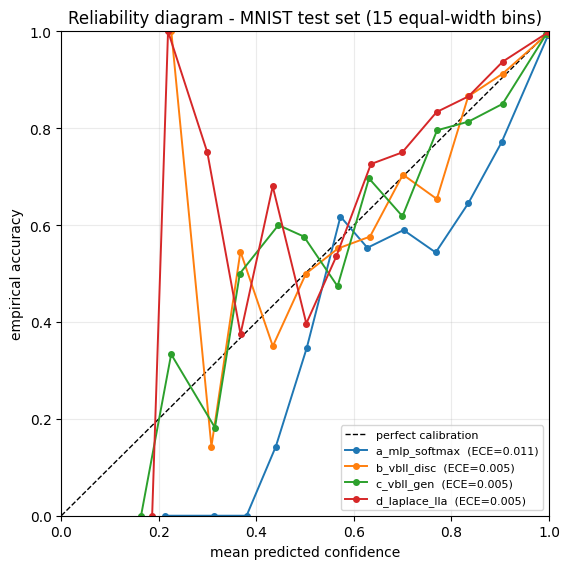

In [17]:
# =============================================================================
# Section 5 - reliability diagram
# =============================================================================
fig, ax = plt.subplots(figsize=(5.8, 5.8))
ax.plot([0, 1], [0, 1], "k--", lw=1.0, label="perfect calibration")

for name, r in RESULTS.items():
    m = r["bin_count"] > 0
    ax.plot(r["bin_conf"][m], r["bin_acc"][m], marker="o", ms=4, lw=1.4,
            label="{}  (ECE={:.3f})".format(name, r["ece"]))

ax.set_xlabel("mean predicted confidence")
ax.set_ylabel("empirical accuracy")
ax.set_title("Reliability diagram - MNIST test set ({} equal-width bins)".format(CFG["n_bins"]))
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.grid(alpha=0.25)
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()

_reliability_path = os.path.join(CFG["fig_dir"], "reliability_diagram.png")
fig.savefig(_reliability_path, dpi=150)
print("saved", _reliability_path)

# Bin occupancy is the main caveat on the equal-width ECE: on a saturated benchmark
# most bins are empty and nearly all the mass sits in the top one, so the headline
# number is dominated by that single bin. Printed here rather than left implicit.
print()
print("equal-width bin occupancy on the ID test set ({} bins):".format(CFG["n_bins"]))
for name, r in RESULTS.items():
    occupied = int((r["bin_count"] > 0).sum())
    top_mass = float(r["bin_count"][-1]) / float(r["n_id"])
    print("  {:<16} non-empty bins {:>2d}/{}   mass in top bin {:.3f}".format(
        name, occupied, CFG["n_bins"], top_mass))
print("  -> compare the 'ece' and 'ece_eqmass' columns before quoting either.")

saved outputs/figures/ood_histogram_native.png
saved outputs/figures/ood_histogram_entropy.png


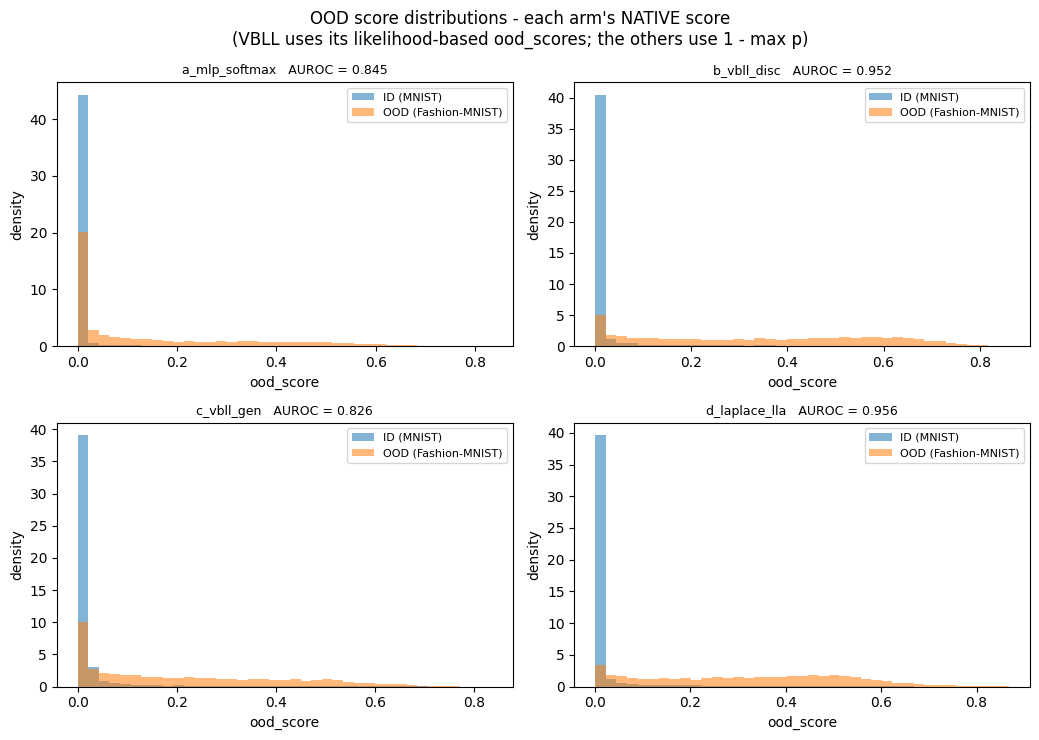

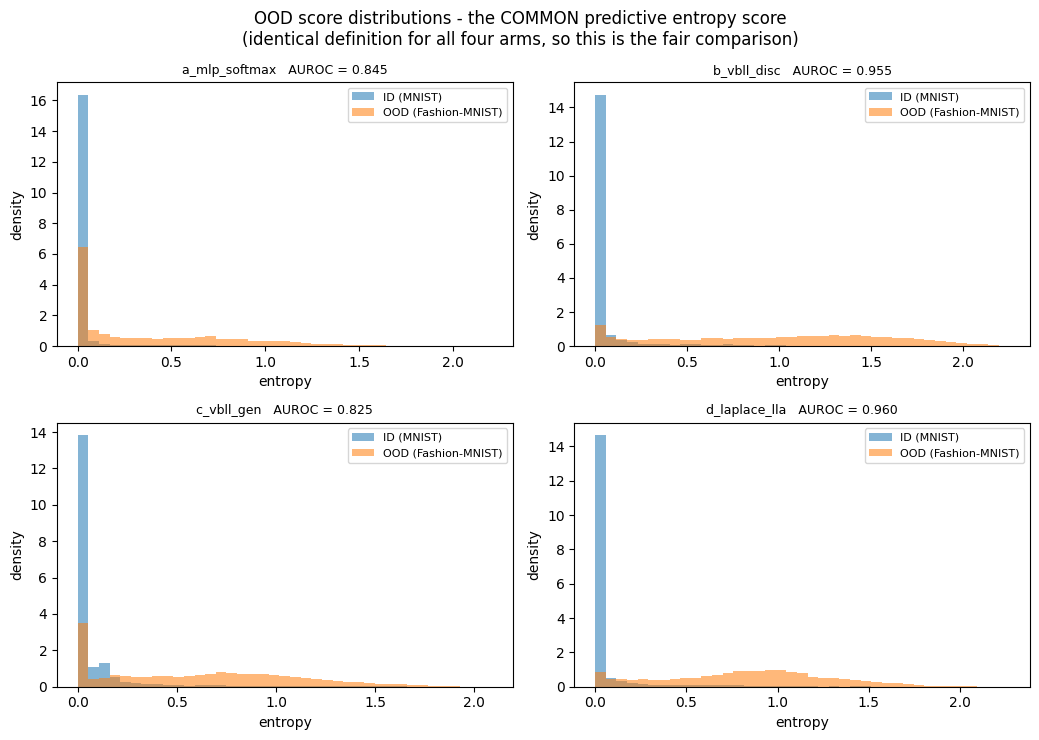

In [18]:
# =============================================================================
# Section 5 - OOD score histograms
# =============================================================================
def plot_ood_grid(score_key: str, auroc_key: str, suptitle: str, fname: str):
    """2x2 grid: ID vs OOD distribution of one score, one panel per arm."""
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.5))

    for ax, (name, r) in zip(axes.ravel(), RESULTS.items()):
        sid = np.asarray(r[score_key + "_id"], dtype=np.float64)
        sood = np.asarray(r[score_key + "_ood"], dtype=np.float64)

        lo = float(min(sid.min(), sood.min()))
        hi = float(max(sid.max(), sood.max()))
        if hi <= lo:
            hi = lo + 1e-6
        bins = np.linspace(lo, hi, 40)

        ax.hist(sid, bins=bins, alpha=0.55, density=True, label="ID (MNIST)")
        ax.hist(sood, bins=bins, alpha=0.55, density=True, label="OOD (Fashion-MNIST)")
        ax.set_title("{}   AUROC = {:.3f}".format(name, r[auroc_key]), fontsize=9)
        ax.set_xlabel(score_key)
        ax.set_ylabel("density")
        ax.legend(fontsize=8)

    fig.suptitle(suptitle)
    fig.tight_layout()
    path = os.path.join(CFG["fig_dir"], fname)
    fig.savefig(path, dpi=150)
    print("saved", path)


plot_ood_grid(
    "ood_score", "auroc_native",
    "OOD score distributions - each arm's NATIVE score\n"
    "(VBLL uses its likelihood-based ood_scores; the others use 1 - max p)",
    "ood_histogram_native.png",
)

plot_ood_grid(
    "entropy", "auroc_entropy",
    "OOD score distributions - the COMMON predictive entropy score\n"
    "(identical definition for all four arms, so this is the fair comparison)",
    "ood_histogram_entropy.png",
)

saved outputs/figures/risk_coverage.png


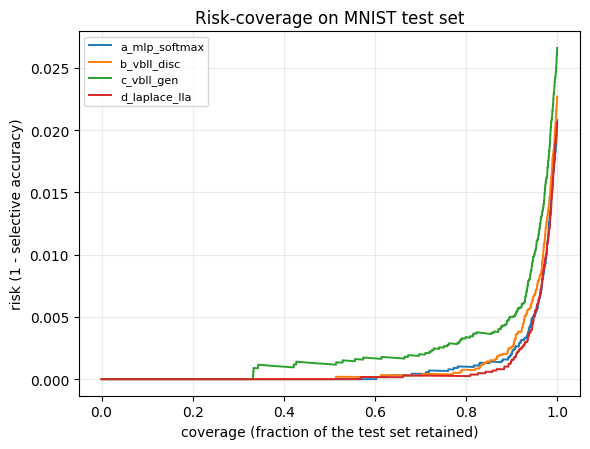

In [19]:
# =============================================================================
# Section 5 - risk-coverage (selective prediction)
# =============================================================================
# Reuses `probs` only, so it costs no new model code.
fig, ax = plt.subplots(figsize=(6.0, 4.6))

for name, r in RESULTS.items():
    conf = r["probs_id"].max(axis=1)
    correct = (r["probs_id"].argmax(axis=1) == r["y_id"]).astype(np.float64)

    order = np.argsort(-conf)                       # most confident first
    c = correct[order]
    n = len(c)
    coverage = np.arange(1, n + 1) / n
    risk = 1.0 - np.cumsum(c) / np.arange(1, n + 1)

    ax.plot(coverage, risk, lw=1.4, label=name)

ax.set_xlabel("coverage (fraction of the test set retained)")
ax.set_ylabel("risk (1 - selective accuracy)")
ax.set_title("Risk-coverage on MNIST test set")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()

_risk_path = os.path.join(CFG["fig_dir"], "risk_coverage.png")
fig.savefig(_risk_path, dpi=150)
print("saved", _risk_path)

In [20]:
# =============================================================================
# Section 5 - export every artefact the report needs
# =============================================================================
results_df.to_csv(os.path.join(CFG["out_dir"], "results.csv"))

_PER_SAMPLE_KEYS = (
    "y_id", "probs_id", "probs_ood", "ood_score_id", "ood_score_ood",
    "entropy_id", "entropy_ood", "bin_conf", "bin_acc", "bin_count", "bin_edges",
)

export = {
    "environment": ENV_INFO,
    "config": {k: v for k, v in CFG.items()},
    "link_approx_used": LINK_APPROX_MAP[CFG["laplace_link_approx"]],
    "laplace_prior_precision": RUN["prior_precision"],
    "backbone_params": BACKBONE_PARAMS,
    "arm_params": {name: count_params(m) for name, m in trained_models.items()},
    "results": {
        name: {k: v for k, v in r.items() if k not in _PER_SAMPLE_KEYS and k != "extra"}
        for name, r in RESULTS.items()
    },
    "provenance": {name: r["extra"] for name, r in RESULTS.items()},
    "figures": sorted(os.listdir(CFG["fig_dir"])),
}

with open(os.path.join(CFG["out_dir"], "results.json"), "w", encoding="utf-8") as f:
    json.dump(export, f, indent=2, default=str)

print("wrote", os.path.join(CFG["out_dir"], "results.csv"))
print("wrote", os.path.join(CFG["out_dir"], "results.json"))
print("figures in {}:".format(CFG["fig_dir"]))
for _f in sorted(os.listdir(CFG["fig_dir"])):
    print("   ", _f)

wrote outputs/results.csv
wrote outputs/results.json
figures in outputs/figures:
    ood_histogram_entropy.png
    ood_histogram_native.png
    reliability_diagram.png
    risk_coverage.png
    sanity_data.png


## Why one seed is not evidence

Every number in the table above comes from a **single** training run per arm. Two
consequences follow, and both matter for how the report should be read:

1. **A single run cannot separate a real effect from noise.** Two arms differing by
   0.3% accuracy might differ by that much on any given day. Nothing in the main
   table has an error bar, so no difference in it should be described as an
   improvement without qualification.
2. **The arms share one train/validation split but not one initialisation.** Each arm
   starts from different random weights, so the comparison is between-arm *variability
   included*, not a paired comparison.

Section 6 addresses the first point with a multi-seed loop and the second with the
ablation hooks. Both are gated behind `CFG['run_robustness']` so that the default
notebook stays inside one Colab session - the same "prove the pipeline end-to-end
first, spend GPU hours second" discipline used in Assignment #1.

In [21]:
# =============================================================================
# Section 6 - multi-seed robustness (gated)
# =============================================================================
if not CFG["run_robustness"]:
    print("Section 6 is OFF.")
    print("The main table is a single-seed result; differences in it should not be")
    print("read as significant. To quantify the noise, set CFG['run_robustness'] = True")
    print("and re-run this cell (and the ablation cell below).")
    print("Cost: roughly 15-20 minutes per additional seed on a T4.")
else:
    multi_rows = []
    for s in CFG["seeds"]:
        print("=" * 74)
        print("seed {}".format(s))
        print("=" * 74)
        run_s = run_pipeline(s, CFG, verbose=False)
        models_s, la_s = run_s["models"], run_s["laplace"]

        adapters_s = [
            BaselineAdapter(models_s["a_mlp_softmax"], "a_mlp_softmax"),
            VBLLAdapter(models_s["b_vbll_disc"], "b_vbll_disc"),
            VBLLAdapter(models_s["c_vbll_gen"], "c_vbll_gen"),
            LaplaceAdapter(
                la_s, "d_laplace_lla",
                link_approx=LINK_APPROX_MAP[CFG["laplace_link_approx"]],
                n_samples=CFG["laplace_n_samples"],
                batch_size=CFG["laplace_batch_size"],
                diagonal_output=CFG["laplace_diagonal_output"],
            ),
        ]
        for ad in adapters_s:
            r = evaluate_model(ad, test_loader, ood_loader, n_bins=CFG["n_bins"])
            multi_rows.append({
                "seed": s,
                "arm": ad.name,
                "accuracy": r["accuracy"],
                "nll": r["nll"],
                "ece": r["ece"],
                "auroc_native": r["auroc_native"],
                "auroc_entropy": r["auroc_entropy"],
            })
            print("  {:<16} acc={:.4f} nll={:.4f} ece={:.4f} auroc_nat={:.4f}".format(
                ad.name, r["accuracy"], r["nll"], r["ece"], r["auroc_native"]))

    multi_df = pd.DataFrame(multi_rows)
    multi_df.to_csv(os.path.join(CFG["out_dir"], "results_multiseed_raw.csv"), index=False)

    multi_summary = multi_df.groupby("arm")[
        ["accuracy", "nll", "ece", "auroc_native", "auroc_entropy"]
    ].agg(["mean", "std"])
    multi_summary.to_csv(os.path.join(CFG["out_dir"], "results_multiseed.csv"))
    print()
    print(multi_summary.to_string())
    multi_summary

Section 6 is OFF.
The main table is a single-seed result; differences in it should not be
read as significant. To quantify the noise, set CFG['run_robustness'] = True
and re-run this cell (and the ablation cell below).
Cost: roughly 15-20 minutes per additional seed on a T4.


In [22]:
# =============================================================================
# Section 6 - ablation hooks (gated)
# =============================================================================
if not CFG["run_robustness"]:
    print("Ablations are OFF. Set CFG['run_robustness'] = True to run them.")
    print("They answer three questions the main table cannot:")
    print("  1. how much does the covariance parameterisation matter?")
    print("  2. how much does the prior scale matter?")
    print("  3. what happens when the head is built WITHOUT return_ood?")
else:
    ABLATIONS = [
        ("disc_diagonal",  dict(kind="disc", parameterization="diagonal")),
        ("disc_dense",     dict(kind="disc", parameterization="dense")),
        ("disc_lowrank",   dict(kind="disc", parameterization="lowrank")),
        ("disc_prior_0.1", dict(kind="disc", prior_scale=0.1)),
        ("disc_prior_10",  dict(kind="disc", prior_scale=10.0)),
        ("disc_no_ood",    dict(kind="disc", return_ood=False)),
    ]

    abl_rows = []
    for tag, kw in ABLATIONS:
        print("=" * 74)
        print("ablation: {}".format(tag))
        print("=" * 74)

        set_seed(CFG["seed"])
        model_a = build_vbll_model(**kw)
        _, best_a = train_model(model_a, train_loader, val_loader, CFG, tag=tag)

        if kw.get("return_ood", True) is False:
            # The point of this ablation is that the adapter must fail LOUDLY,
            # by name, rather than raising a bare AttributeError somewhere later.
            try:
                VBLLAdapter(model_a, tag).predict(test_loader)
                note = "adapter did NOT raise - unexpected"
            except RuntimeError as err:
                note = "adapter raised as designed: " + str(err)[:70]
            abl_rows.append({
                "ablation": tag,
                "accuracy": round(best_a["val_acc"], 4),
                "nll": np.nan, "ece": np.nan, "auroc_native": np.nan,
                "note": note,
            })
            print("  " + note)
        else:
            r_a = evaluate_model(VBLLAdapter(model_a, tag), test_loader, ood_loader,
                                 n_bins=CFG["n_bins"])
            abl_rows.append({
                "ablation": tag,
                "accuracy": round(r_a["accuracy"], 4),
                "nll": round(r_a["nll"], 4),
                "ece": round(r_a["ece"], 4),
                "auroc_native": round(r_a["auroc_native"], 4),
                "note": "",
            })
            print("  acc={:.4f} nll={:.4f} ece={:.4f} auroc_native={:.4f}".format(
                r_a["accuracy"], r_a["nll"], r_a["ece"], r_a["auroc_native"]))

    abl_df = pd.DataFrame(abl_rows)
    abl_df.to_csv(os.path.join(CFG["out_dir"], "results_ablations.csv"), index=False)
    print()
    print(abl_df.to_string(index=False))
    abl_df

Ablations are OFF. Set CFG['run_robustness'] = True to run them.
They answer three questions the main table cannot:
  1. how much does the covariance parameterisation matter?
  2. how much does the prior scale matter?
  3. what happens when the head is built WITHOUT return_ood?


## Threats to validity - stated plainly

**1. MNIST is a saturated benchmark.** Any reasonable MLP reaches ~98% test accuracy
here, so the accuracy column separates the arms hardly at all. The interesting
columns are NLL, ECE and AUROC. The report should not lead with accuracy.

**2. One seed per configuration, unless Section 6 is run.** The main table has no
error bars. Any claim of the form "arm X beats arm Y" needs either the multi-seed
summary or an explicit caveat.

**3. The four OOD scores are not the same quantity.** `auroc_native` compares a
likelihood-based score (VBLL), a max-softmax score (the baseline), a derived
max-softmax score (Laplace), and a generative score (VBLL-Gen) - four different
functions of the data. Only `auroc_entropy` is defined identically for all four arms.
The report must present both and say which is which.

**4. The discriminative and generative VBLL losses are not numerically comparable.**
`DiscClassification` optimises a Jensen bound on a discriminative softmax;
`GenClassification` optimises a class-conditional likelihood over the input. Their
training losses live on different scales and mean different things. **Losses must
never be compared across arms in the report** - only metrics.

**5. The Laplace GLM predictive is an approximation.** It linearises the network
around the MAP estimate and then applies a link approximation on top
(`mc` = Monte-Carlo, `probit` = closed-form multiclass probit). The choice of
`CFG['laplace_link_approx']` changes the probabilities, and therefore the ECE and the
derived OOD score. Whichever value was used must be quoted in the report - the
notebook records it in `results.json` under `link_approx_used`.

**6. Arm (d) is not protocol-matched to arms (a)-(c).** Its base network is trained
the same way, but the Laplace posterior is fitted afterwards with a
validation-tuned prior precision. That is inherent to a post-hoc method; it is
mentioned so the comparison is not over-claimed.

**7. The VBLL predictive contains a fixed internal Monte-Carlo average** (20 samples,
hard-coded in the library). VBLL is "sampling-free" in the sense that no MC loop is
needed to obtain the posterior, but the *predictive* itself is computed by averaging
samples internally. The notebook pins the RNG around those calls so the numbers are
reproducible, but the 20-sample average is still an approximation of the VBLL
predictive and is not a tunable of this experiment.

**8. Non-deterministic cuDNN kernels.** Runs are seeded but not bit-reproducible.

**9. ECE is sensitive to the binning convention, and equal-width bins are lopsided
here.** On a saturated benchmark most test samples sit in the top equal-width bin
(the notebook prints the occupancy, and it is typically ~90%+ of the test set), so the
headline ECE is dominated by that one bin. The `ece_eqmass` column repeats the
measurement with equal-mass bins, which spreads the weight across the confidence
range. The two numbers answer slightly different questions and should be quoted
together; neither is "the" ECE.

---

### What each result feeds into in the report

| Report section | Produced by |
|---|---|
| (1) How the algorithm was found | the literature search - not this notebook |
| (2) Description of the algorithm | not this notebook (theory section) |
| (3) How the AI implemented it | this notebook: the adapter contract, the unified training loop, the two-softmax guard |
| (4) Experiment settings and results | `results.csv` / `results.json`, and the four figures |
| (5) What was learnt | the threats above, plus the multi-seed and ablation results if Section 6 was run |
| (6) Source-code link | the published notebook itself |